In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# load rho-10kb file
data = pd.read_csv("./Mbel/concat_Mbel_excl5scaff_rmind_hardfilt_exhet_biall_dp_qfilt_mac2_maxmiss06_phimp_LDhat_bpen1_statres_100N_filtMQ70depth2stdev.txt_w10kb", sep='\t')
data = data.sort_values(by=['Scaffold', 'Start_bp'])

In [7]:
braker = pd.read_csv("./Mbel/braker.gff3_red", sep="\t")

In [13]:
br = braker.loc[braker["Type"]!="CDS"]

In [14]:
br.head()

,Scaffold,Type,Start_pos,End_pos,ID
0,scaffold1,start_codon,38182802,38182804,g21734.t1.start1
2,scaffold1,exon,38182802,38182838,g21734.t1.exon1
3,scaffold1,intron,38182839,38182894,g21734.t1.intron1
5,scaffold1,exon,38182895,38182961,g21734.t1.exon2
6,scaffold1,intron,38182962,38183017,g21734.t1.intron2


In [23]:
def get_gene_density(gff3, rho, winsize="10000"):
    
    win_dict = {}
    win_size = winsize
    for i, te in gff3.iterrows():
        
        # check bin TE is starting in:
        bin_id = np.floor((te.Start_pos/win_size))
        bin_bottom= bin_id*win_size
        bin_top = (bin_id+1)*win_size
        win_dict.setdefault(te.Scaffold, {}).setdefault(bin_id, {"counter":0,'type':[],"frac":0, "lens":[] })
        win_dict[te.Scaffold][bin_id]["counter"] +=1
        win_dict[te.Scaffold][bin_id]["type"].append(te["Type"])
        
        frac = (np.min([bin_top,te.End_pos]) - np.max([bin_bottom, te.Start_pos]))
        win_dict[te.Scaffold][bin_id]["lens"].append(frac)
        win_dict[te.Scaffold][bin_id]["frac"] += frac
        while te.End_pos>(bin_top*win_size):
            bin_id = bin_id+1
            bin_bottom= bin_id*win_size
            bin_top = (bin_id+1)*win_size
            win_dict.setdefault(te.Scaffold, {}).setdefault(bin_id, {"counter":0,'type':[],"frac":0, "lens":[] })
            win_dict[te.Scaffold][bin_id]["counter"] +=1
            win_dict[te.Scaffold][bin_id]["type"].append(te.Type)
            frac = (np.min([bin_top,te.End_pos]) - np.max([bin_bottom, te.Start_pos]))
            win_dict[te.Scaffold][bin_id]["lens"].append(frac)
            win_dict[te.Scaffold][bin_id]["frac"] += frac
            
 
    frac_df_all = []
    for scaffold, item in win_dict.items():
        for bin_name, values in item.items():
            line = [scaffold, bin_name*win_size, (bin_name+1)*win_size, values['frac']]
            frac_df_all.append(line)
    frac_df_all = pd.DataFrame(frac_df_all)
    frac_df_all.columns = ["scaffold", 'start_bin', "stop_win", "frac_rep"]
    frac_rho = rho.merge(frac_df_all, left_on=["Scaffold", "Start_bp"], right_on=["scaffold", "start_bin"])
    return win_dict, frac_rho

In [24]:
wd, fr = get_gene_density(gff3=br, rho=data, winsize=10000)

In [27]:
import scipy as sc

In [28]:
sc.stats.spearmanr(a=fr["Rho_kb"], b=fr["frac_rep"])

SignificanceResult(statistic=-0.1987222563358415, pvalue=0.0)

In [39]:
sns.displot

<function seaborn.distributions.displot(data=None, *, x=None, y=None, hue=None, row=None, col=None, weights=None, kind='hist', rug=False, rug_kws=None, log_scale=None, legend=True, palette=None, hue_order=None, hue_norm=None, color=None, col_wrap=None, row_order=None, col_order=None, height=5, aspect=1, facet_kws=None, **kwargs)>

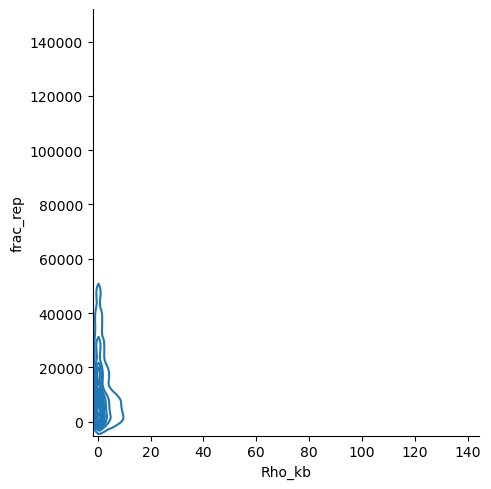

In [42]:
sns.displot(x=fr.Rho_kb, y=fr.frac_rep, kind="kde")

<Axes: xlabel='frac_rep', ylabel='Rho_kb'>

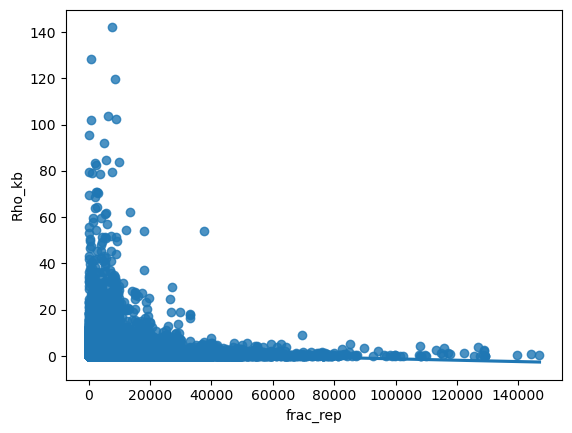

In [31]:
sns.regplot(y=fr.Rho_kb, x=fr.frac_rep.)

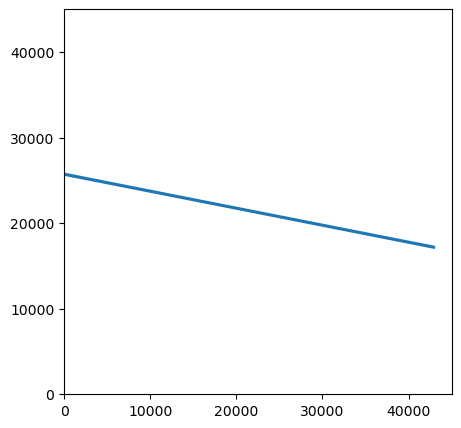

In [62]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5,5))
sns.regplot(y=sc.stats.rankdata(fr.Rho_kb), x=sc.stats.rankdata(fr.frac_rep), scatter=False, scatter_kws={"alpha":0.1}, ax=ax)

ax.set_xlim(-10,45_000)
ax.set_ylim(-10,45_000)
plt.show()

array([15044., 10536., 27351., ..., 25546., 14686., 22674.])

In [32]:
import statsmodels.api as sm

In [35]:
rr = sm.formula.ols("Rho_kb ~ frac_rep", data=fr)
rfit= rr.fit()
rfit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Rho_kb   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     277.7
Date:                Thu, 01 Feb 2024   Prob (F-statistic):           3.70e-62
Time:                        22:50:29   Log-Likelihood:            -1.1676e+05
No. Observations:               42907   AIC:                         2.335e+05
Df Residuals:                   42905   BIC:                         2.335e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6705      0.024     70.444      0.000       1.624       1.717
frac_rep    -2.92e-05   1.75e-06    -16.665      0.000   -3.26e-05   -2.58e-05
==============================================================================
Omnibus:                    75753.791   Durbin-Watson:                   1.110
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        129605167.914
Skew:                          12.555   Prob(JB):                         0.00
Kurtosis:                     271.075   Cond. No.                     1.81e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""